<a href="https://colab.research.google.com/github/Rahmi1635/MachineLearningExamples/blob/main/iris_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [21]:
#Veri Yükleme
iris=load_iris()
X=iris.data
y=iris.target

In [33]:
# Train/Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=50)

In [23]:
# Scaling
scaling=StandardScaler()
X_train=scaling.fit_transform(X_train)
X_test=scaling.transform(X_test)

In [39]:
# Model
k_values=list(range(1,21))
train_accuracies=[]
test_accuracies=[]
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    train_accuracies.append(accuracy_score(y_train,y_train_pred))

    y_test_pred=model.predict(X_test)
    test_accuracies.append(accuracy_score(y_test,y_test_pred))


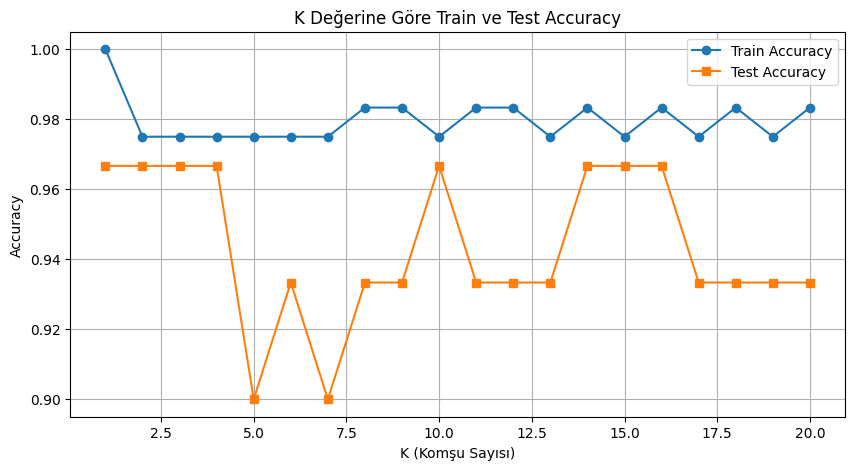

In [43]:
# Görselleştirme
plt.figure(figsize=(10,5))
plt.plot(k_values, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(k_values, test_accuracies, marker='s', label='Test Accuracy')
plt.xlabel("K (Komşu Sayısı)")
plt.ylabel("Accuracy")
plt.title("K Değerine Göre Train ve Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
#Cross Validation kullanarak eğitim setini bölmek bu sayede perfrmans tahmini için doğruluk seviyesini arttırma
scores=cross_val_score(model,X,y,cv=5)
print(scores)
print("Mean : ",scores.mean())

[0.93333333 1.         0.93333333 0.93333333 1.        ]
Mean :  0.96


In [25]:
# Tahmin
y_pred=model.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0
